# Golbal_WebTraffic_Analysis Report 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load dataset
df = pd.read_csv(r'C:\Users\admin\Documents\Ai.mL\python\global_web_traffic_dataset.csv')
df.head()

,visit_id,date,country,traffic_source,device_type,browser,page,session_duration_sec,pages_viewed,bounce,conversion
0,1,13-04-2025,Turkey,Referral,Desktop,Chrome,/about,49,7,0,0
1,2,15-12-2025,Turkey,Social Media,Mobile,Chrome,/blog,785,3,0,0
2,3,28-09-2025,India,Direct,Desktop,Safari,/blog,1734,13,0,0
3,4,17-04-2025,Italy,Organic Search,Mobile,Opera,/blog,529,5,0,0
4,5,13-03-2025,Mexico,Email,Mobile,Opera,/contact,1649,10,1,0


## 1. Data Preparation

In [7]:
# Convert 'VisitDate' to datetime
df['date'] = pd.to_datetime(df['date'])

df['Month'] = df['date'].dt.month_name()
df['DayOfWeek'] = df['date'].dt.day_name()
df['Week'] = df['date'].dt.isocalendar().week

# Handle missing values
df['session_duration_sec'] = df['session_duration_sec'].fillna(df['session_duration_sec'].mean())
df['pages_viewed'] = df['pages_viewed'].fillna(df['pages_viewed'].median())
df

,visit_id,date,country,traffic_source,device_type,browser,page,session_duration_sec,pages_viewed,bounce,conversion,Month,DayOfWeek,Week
0,1,2025-04-13,Turkey,Referral,Desktop,Chrome,/about,49,7,0,0,April,Sunday,15
1,2,2025-12-15,Turkey,Social Media,Mobile,Chrome,/blog,785,3,0,0,December,Monday,51
2,3,2025-09-28,India,Direct,Desktop,Safari,/blog,1734,13,0,0,September,Sunday,39
3,4,2025-04-17,Italy,Organic Search,Mobile,Opera,/blog,529,5,0,0,April,Thursday,16
4,5,2025-03-13,Mexico,Email,Mobile,Opera,/contact,1649,10,1,0,March,Thursday,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,2025-06-14,China,Referral,Desktop,Opera,/contact,278,1,1,0,June,Saturday,24
1996,1997,2025-11-01,USA,Social Media,Desktop,Opera,/login,1053,13,1,0,November,Saturday,44
1997,1998,2025-04-30,Saudi Arabia,Email,Mobile,Edge,/home,587,2,0,0,April,Wednesday,18
1998,1999,2025-02-13,Italy,Direct,Mobile,Chrome,/contact,1004,10,0,0,February,Thursday,7


In [6]:
df.head()

,visit_id,date,country,traffic_source,device_type,browser,page,session_duration_sec,pages_viewed,bounce,conversion,Month,DayOfWeek,Week
0,1,2025-04-13,Turkey,Referral,Desktop,Chrome,/about,49,7,0,0,April,Sunday,15
1,2,2025-12-15,Turkey,Social Media,Mobile,Chrome,/blog,785,3,0,0,December,Monday,51
2,3,2025-09-28,India,Direct,Desktop,Safari,/blog,1734,13,0,0,September,Sunday,39
3,4,2025-04-17,Italy,Organic Search,Mobile,Opera,/blog,529,5,0,0,April,Thursday,16
4,5,2025-03-13,Mexico,Email,Mobile,Opera,/contact,1649,10,1,0,March,Thursday,11


## 2. Traffic Trend Analysis

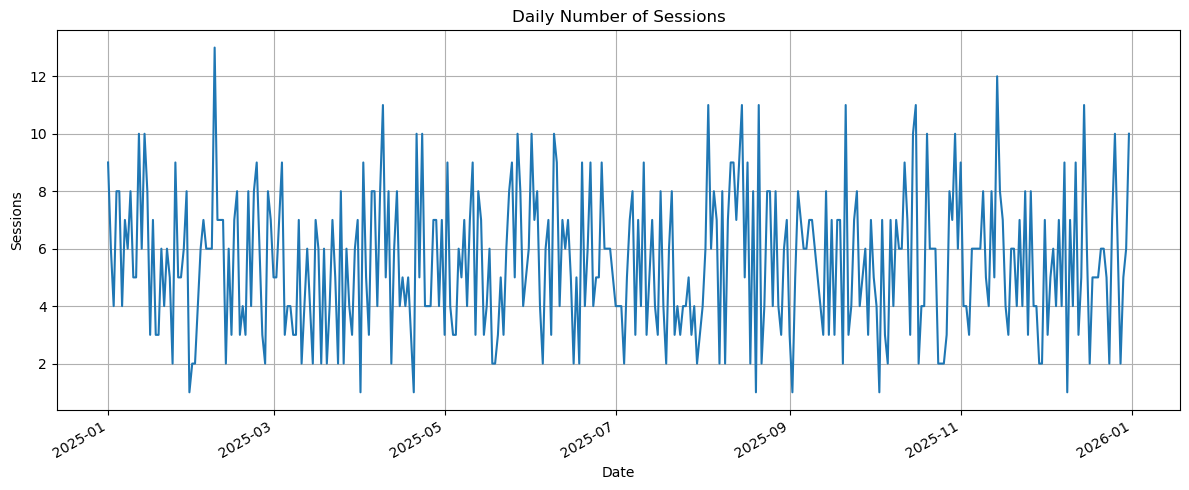

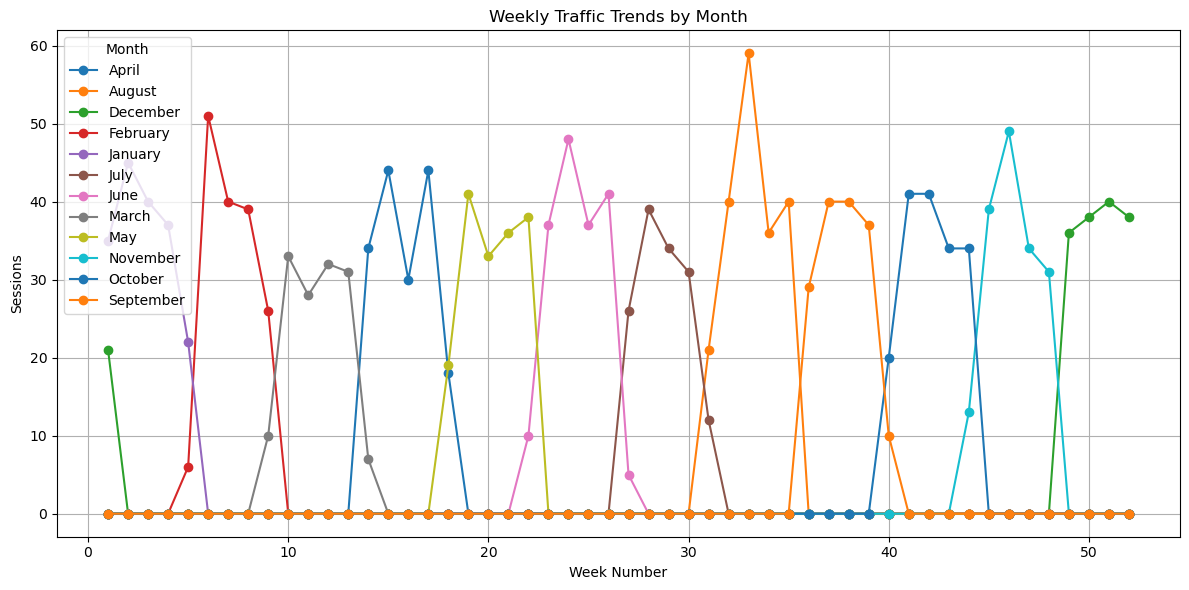

In [8]:
# Daily number of sessions
daily_sessions = df.groupby('date').size()

'''
The `size()` method in the line:

df.groupby('VisitDate').size() is used to count the number of rows (i.e., occurrences or entries) in each group formed by `groupby()`.

### Here's what happens step by step:

1. `df.groupby('VisitDate')`:  
   Groups the DataFrame by each unique `VisitDate`.

2. `.size()`:  
   Counts the number of entries (rows) in each group, returning a `Series` with the `VisitDate` as the index and the count as the value.

### Example:
Suppose the `df` has this data:

| VisitDate  | SessionID |
|------------|-----------|
| 2025-01-01 | A1        |
| 2025-01-01 | A2        |
| 2025-01-02 | A3        |

Then:
df.groupby('VisitDate').size()

Would return:

VisitDate
2025-01-01    2
2025-01-02    1
dtype: int64

This tells you that:
- 2 sessions occurred on Jan 1, 2025
- 1 session occurred on Jan 2, 2025
'''

plt.figure(figsize=(12, 5))
daily_sessions.plot()
plt.title('Daily Number of Sessions')
plt.xlabel('Date')
plt.ylabel('Sessions')
plt.grid(True)
plt.tight_layout()
plt.show()

# Weekly traffic trends by month
weekly_trends = df.groupby(['Week', 'Month']).size().unstack().fillna(0)

'''
The expression:

df.groupby(['Week', 'Month']).size().unstack().fillna(0)
is used to create a pivot-style table showing the count of records per week, 
broken down by month. 

Let’s break it down:

---

### 1. `df.groupby(['Week', 'Month'])`
This groups the DataFrame by both `Week` and `Month`.

Example group structure:
(Week 1, January), (Week 2, January), (Week 1, February), ...

---

### 2. `.size()`
Counts the number of rows (sessions/visits) in each `(Week, Month)` group.

Output so far (MultiIndex Series):
Week  Month
1     January     12
1     February     5
2     January     20
2     February    10
...

---

### 3. `.unstack()`
"Unstacks" the `Month` index level to become columns instead of part of the row index.

Now you get a table like:
| Week | January | February | March |
|------|---------|----------|-------|
| 1    |   12    |    5     |  NaN  |
| 2    |   20    |   10     |   8   |

---

### 4. `.fillna(0)`
Replaces all `NaN` values (which indicate no data for a week-month pair) with `0`.

Final output:
| Week | January | February | March |
|------|---------|----------|-------|
| 1    |   12    |    5     |   0   |
| 2    |   20    |   10     |   8   |

---

### Purpose:
To easily visualize or plot weekly session counts broken down by month, 
where missing combinations are filled with `0` instead of `NaN`.
'''

weekly_trends.plot(figsize=(12, 6), marker='o')
plt.title('Weekly Traffic Trends by Month')
plt.xlabel('Week Number')
plt.ylabel('Sessions')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. User Engagement Metrics

In [9]:
# Average metrics
avg_session_duration = df['session_duration_sec'].mean()
avg_page_views = df['pages_viewed'].mean()

print(f'Average Session Duration: {avg_session_duration:.2f} seconds')
print(f'Average Page Views per Session: {avg_page_views:.2f}')

Average Session Duration: 930.60 seconds
Average Page Views per Session: 7.43


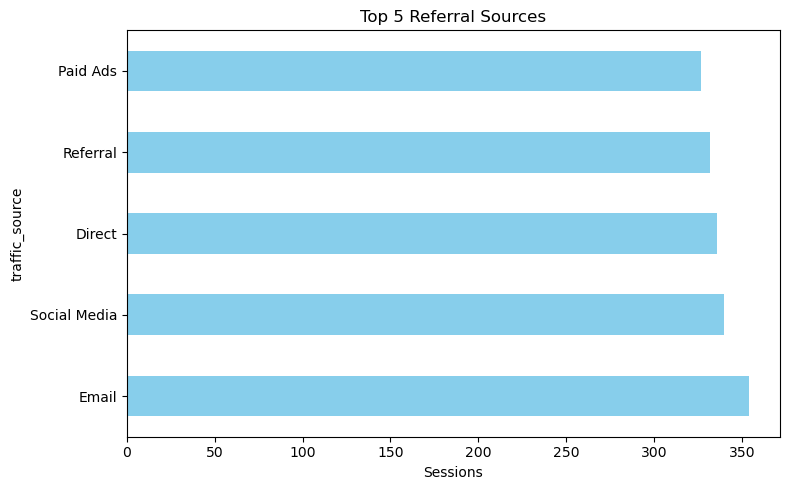

In [10]:
# Top 5 referral sources
top_referrals = df['traffic_source'].value_counts().head(5)

top_referrals.plot(kind='barh', figsize=(8, 5), color='skyblue')
plt.title('Top 5 Referral Sources')
plt.xlabel('Sessions')
plt.tight_layout()
plt.show()

## 4. Conversion Analysis

In [13]:
# Conversion rate
conversion_rate = df['conversion'].mean() * 100

print(f'Overall Conversion Rate: {conversion_rate:.2f}%')

Overall Conversion Rate: 10.05%


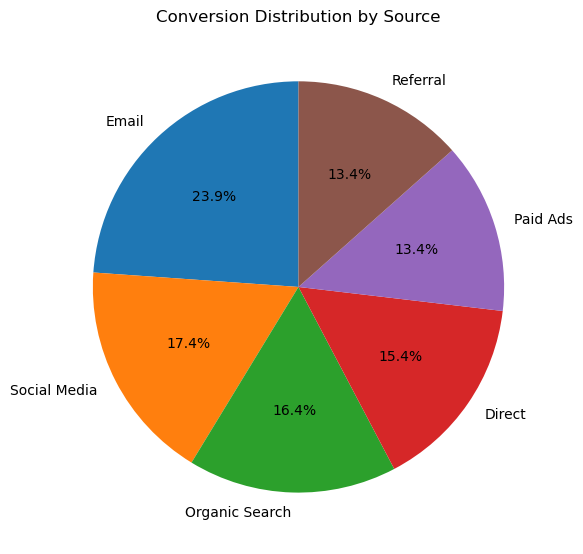

In [14]:
# Pie chart by source
source_conversions = df[df['conversion'] == 1]['traffic_source'].value_counts()

source_conversions.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), startangle=90)
plt.title('Conversion Distribution by Source')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5. Device & Platform Insights

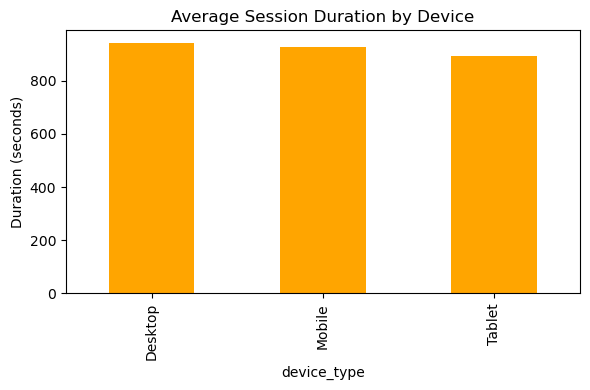

In [16]:
# Average session duration by device
device_duration = df.groupby('device_type')['session_duration_sec'].mean()

device_duration.plot(kind='bar', figsize=(6, 4), color='orange')
plt.title('Average Session Duration by Device')
plt.ylabel('Duration (seconds)')
plt.tight_layout()
plt.show()

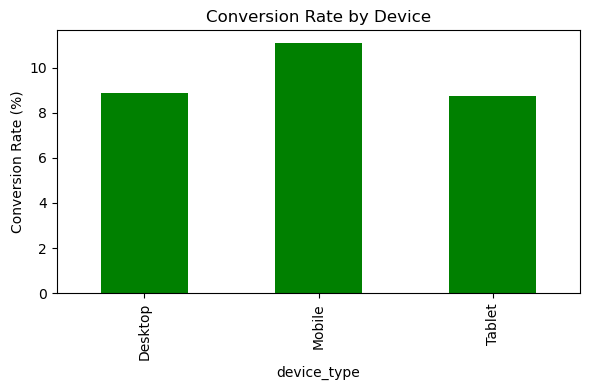

In [18]:
# Conversion rate by device
device_conversion = df.groupby('device_type')['conversion'].mean() * 100

device_conversion.plot(kind='bar', figsize=(6, 4), color='green')
plt.title('Conversion Rate by Device')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

## 6. Bounce Rate Pattern

In [20]:
df.head()

,visit_id,date,country,traffic_source,device_type,browser,page,session_duration_sec,pages_viewed,bounce,conversion,Month,DayOfWeek,Week
0,1,2025-04-13,Turkey,Referral,Desktop,Chrome,/about,49,7,0,0,April,Sunday,15
1,2,2025-12-15,Turkey,Social Media,Mobile,Chrome,/blog,785,3,0,0,December,Monday,51
2,3,2025-09-28,India,Direct,Desktop,Safari,/blog,1734,13,0,0,September,Sunday,39
3,4,2025-04-17,Italy,Organic Search,Mobile,Opera,/blog,529,5,0,0,April,Thursday,16
4,5,2025-03-13,Mexico,Email,Mobile,Opera,/contact,1649,10,1,0,March,Thursday,11


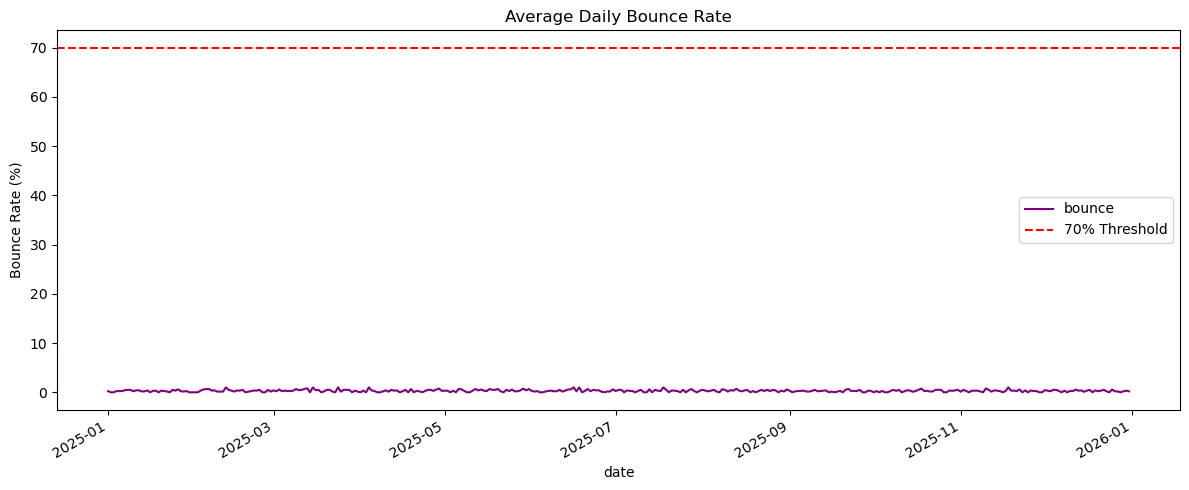

In [21]:
# Daily average bounce rate

daily_bounce = df.groupby('date')['bounce'].mean()

daily_bounce.plot(figsize=(12, 5), color='purple')

plt.axhline(70, color='red', linestyle='--', label='70% Threshold')

plt.title('Average Daily Bounce Rate')
plt.ylabel('Bounce Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()